In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Configurazione stile grafici
plt.style.use('seaborn-v0_8')

# 1. Caricamento del dataset
df = pd.read_csv('../data/puliti/movimento_fe.csv')

print(f"Dataset caricato: {df.shape[0]} giocatori totali.")

Dataset caricato: 15738 giocatori totali.


In [2]:
# 1. Selezione delle colonne numeriche
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Lista di colonne da ESCLUDERE (non sono abilità tecniche)
# Nota: Escludiamo 'OVR' dalle feature di training perché lo usiamo come filtro dopo!
cols_to_exclude = [
    'ID', 'Age', 'OVR', 'Weak Foot', 'Skill Moves'
]
features_to_use = [col for col in numeric_cols if col not in cols_to_exclude]

# Creiamo il dataset X pulito (gestione valori mancanti con la media)
X_all = df[features_to_use].fillna(df[features_to_use].mean())

# 2. Rimozione Feature Ridondanti (Correlazione > 90%)
corr_matrix = X_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Troviamo le colonne troppo simili (es. Acceleration vs Sprint Speed)
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"Feature iniziali: {len(features_to_use)}")
print(f"Feature rimosse per ridondanza: {len(to_drop)}")
print(f"Esempio rimosse: {to_drop[:3]}...")

# Lista finale delle feature utili
final_features = [f for f in features_to_use if f not in to_drop]
print(f"Feature finali utilizzate: {len(final_features)}")

Feature iniziali: 50
Feature rimosse per ridondanza: 11
Esempio rimosse: ['Acceleration', 'Sprint Speed', 'Finishing']...
Feature finali utilizzate: 39


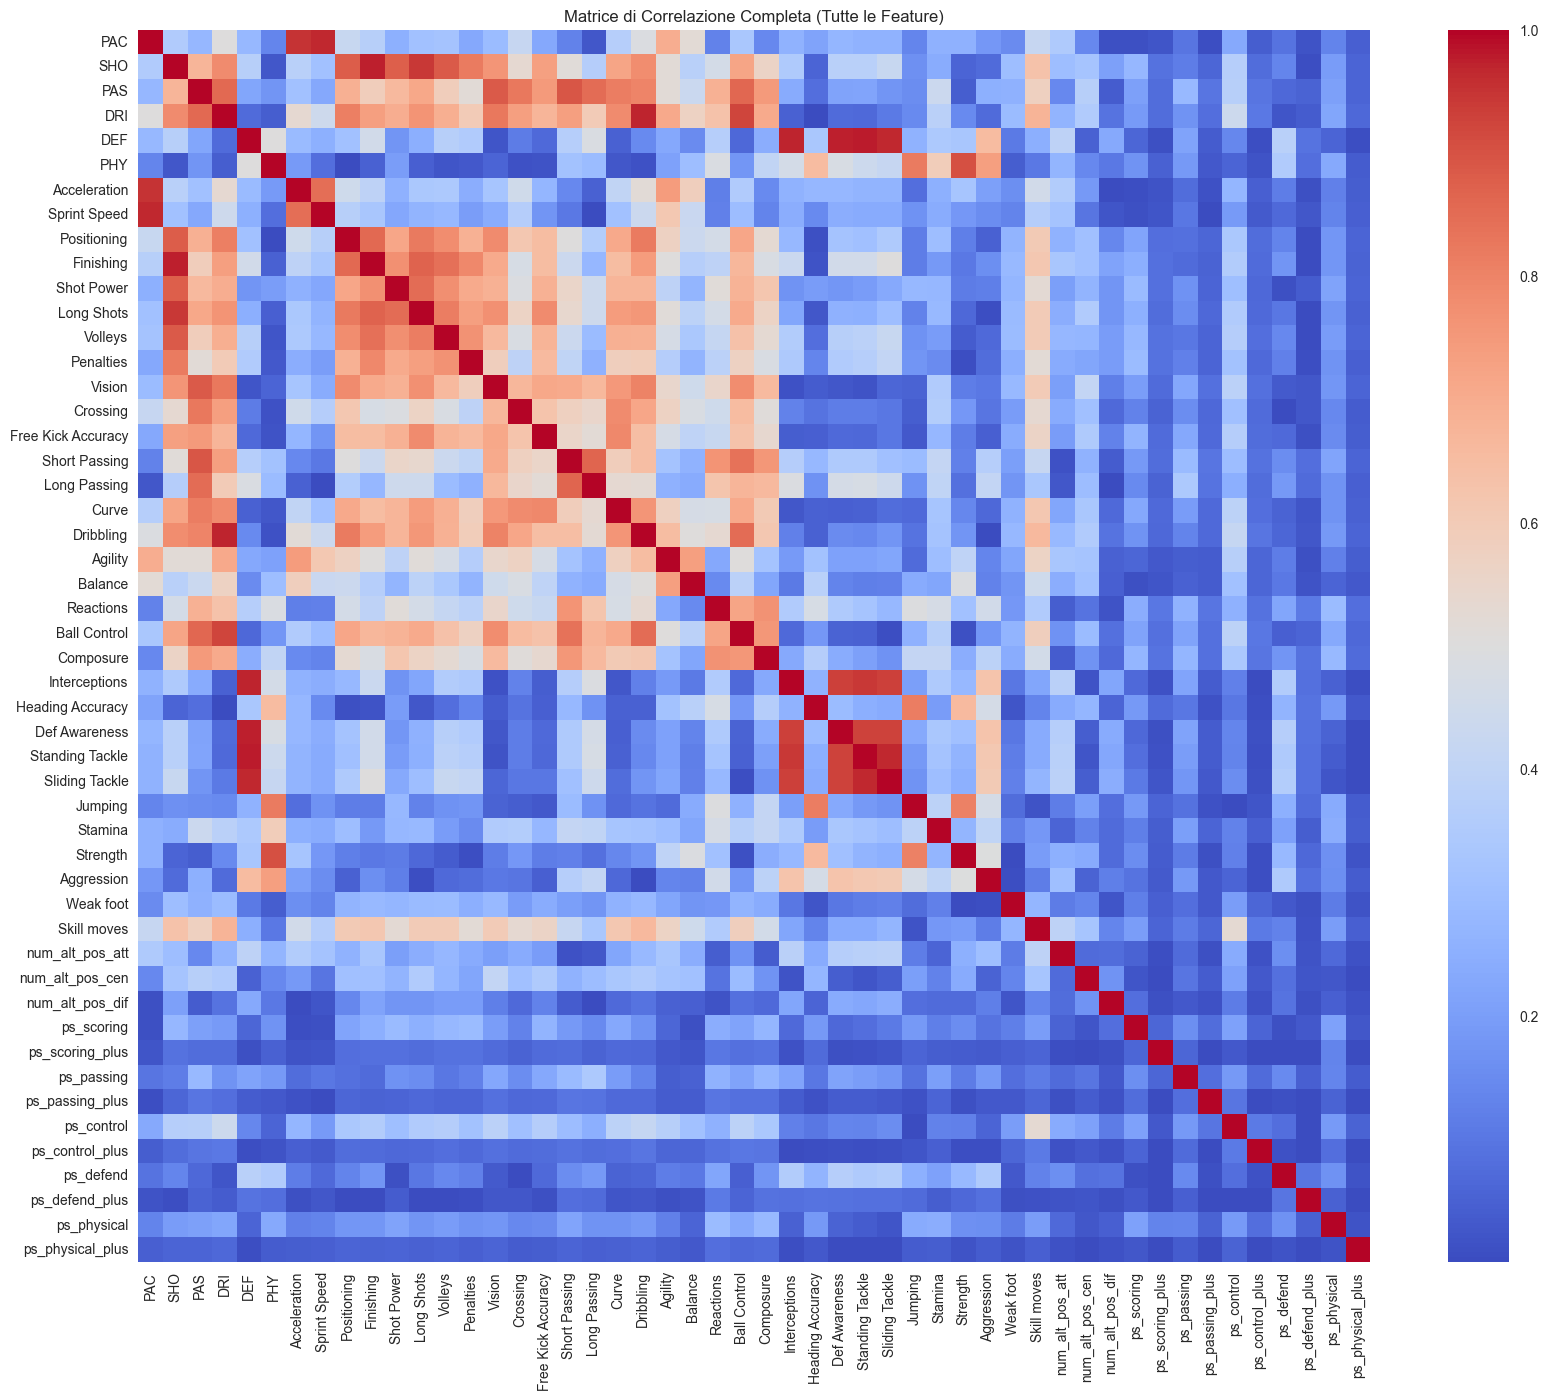

Feature eliminate perché ridondanti (>90% correlazione):
['Acceleration', 'Sprint Speed', 'Finishing', 'Long Shots', 'Dribbling', 'Ball Control', 'Interceptions', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'Strength']


In [3]:
# --- Cella 2-bis: Visualizzazione Correlazione (Richiesta dal Tutor) ---

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', square=True)
plt.title('Matrice di Correlazione Completa (Tutte le Feature)')
plt.show()

print(f"Feature eliminate perché ridondanti (>90% correlazione):")
print(to_drop)

In [4]:
# Imposta la soglia (es. 75 = Giocatori Oro/Top)
soglia_ovr = 75

# Creiamo il sotto-dataset
df_top = df[df['OVR'] >= soglia_ovr].copy()
X_top = df_top[final_features].fillna(df_top[final_features].mean())

print(f"--- FILTRO APPLICATO (OVR >= {soglia_ovr}) ---")
print(f"Giocatori analizzati: {len(df_top)} (su {len(df)} totali)")

--- FILTRO APPLICATO (OVR >= 75) ---
Giocatori analizzati: 2086 (su 15738 totali)


In [5]:
# 1. Standardizzazione (Scaling)
scaler = StandardScaler()
X_top_scaled = scaler.fit_transform(X_top)

# 2. PCA a 3 Componenti
pca = PCA(n_components=3)
X_top_pca = pca.fit_transform(X_top_scaled)

# Creiamo un DataFrame per comodità grafica
pca_df = pd.DataFrame(data=X_top_pca, columns=['PC1', 'PC2', 'PC3'])

print(f"Varianza spiegata dalle 3 componenti: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Varianza spiegata dalle 3 componenti: 49.25%


In [6]:
# --- Cella 4-bis: Interpretazione delle Componenti PCA (Richiesta dal Tutor) ---

# Creiamo un DataFrame con i pesi (loadings) delle feature sulle 3 componenti
loadings = pd.DataFrame(
    pca.components_.T,  # Trasponiamo la matrice dei componenti
    columns=['PC1', 'PC2', 'PC3'],
    index=final_features # Usiamo i nomi delle feature rimaste
)

print("--- INTERPRETAZIONE DELLE COMPONENTI (Cosa rappresentano?) ---")

# Funzione per mostrare le feature più influenti per ogni componente
def show_top_features(component_name, n=5):
    # Ordiniamo per valore assoluto (peso)
    top = loadings[component_name].abs().sort_values(ascending=False).head(n)
    # Recuperiamo il segno originale (+ o -)
    top_features = loadings.loc[top.index, component_name]
    print(f"\n>>> {component_name} è influenzata principalmente da:")
    print(top_features)

show_top_features('PC1')
show_top_features('PC2')
show_top_features('PC3')

--- INTERPRETAZIONE DELLE COMPONENTI (Cosa rappresentano?) ---

>>> PC1 è influenzata principalmente da:
DRI            0.265547
SHO            0.252793
Positioning    0.244115
Curve          0.243284
Vision         0.242792
Name: PC1, dtype: float64

>>> PC2 è influenzata principalmente da:
Long Passing     0.346465
DEF              0.312947
Short Passing    0.312165
Aggression       0.293529
PHY              0.291791
Name: PC2, dtype: float64

>>> PC3 è influenzata principalmente da:
Jumping             0.432307
Heading Accuracy    0.372406
PHY                 0.277483
Long Passing       -0.247493
Shot Power          0.219225
Name: PC3, dtype: float64


Calcolo in corso per Gomito e Silhouette...


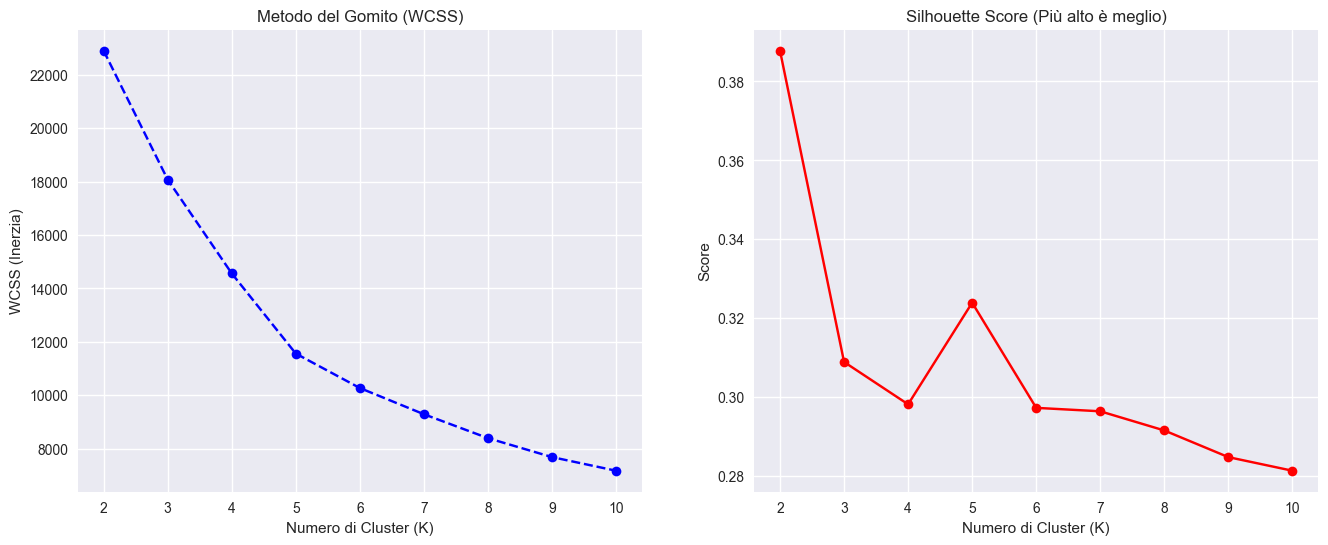

In [7]:
from sklearn.metrics import silhouette_score

# Liste per salvare i risultati
wcss = []
sil_scores = []
K_range = range(2, 11)  # Testiamo da 2 a 10 cluster

print("Calcolo in corso per Gomito e Silhouette...")

for k in K_range:
    # Eseguiamo K-Means su X_top_pca (i dati ridotti dei Top Players)
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_top_pca)
    
    # Salviamo WCSS (Inerzia) e Silhouette
    wcss.append(kmeans_test.inertia_)
    sil_scores.append(silhouette_score(X_top_pca, kmeans_test.labels_))

# --- Creazione dei Grafici ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grafico del Gomito
ax1.plot(K_range, wcss, marker='o', linestyle='--', color='b')
ax1.set_title('Metodo del Gomito (WCSS)')
ax1.set_xlabel('Numero di Cluster (K)')
ax1.set_ylabel('WCSS (Inerzia)')
ax1.grid(True)

# 2. Grafico della Silhouette
ax2.plot(K_range, sil_scores, marker='o', linestyle='-', color='r')
ax2.set_title('Silhouette Score (Più alto è meglio)')
ax2.set_xlabel('Numero di Cluster (K)')
ax2.set_ylabel('Score')
ax2.grid(True)

plt.show()

In [8]:
# K-Means con 3 Cluster
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_top['Cluster_3'] = kmeans3.fit_predict(X_top_pca)

# K-Means con 4 Cluster
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_top['Cluster_4'] = kmeans4.fit_predict(X_top_pca)

print("Clustering completato.")

Clustering completato.


In [9]:
print("\n--- ANALISI TATTICA: CHI C'È NEI GRUPPI? ---")

print("\n>>> Configurazione a 3 CLUSTER (Difesa vs Centrocampo vs Attacco)")
print(pd.crosstab(df_top['Cluster_3'], df_top['Position']))

print("\n>>> Configurazione a 4 CLUSTER (Dettaglio su Terzini/Mediani)")
print(pd.crosstab(df_top['Cluster_4'], df_top['Position']))


--- ANALISI TATTICA: CHI C'È NEI GRUPPI? ---

>>> Configurazione a 3 CLUSTER (Difesa vs Centrocampo vs Attacco)
Position   CAM   CB  CDM   CM  LB   LM  LW  RB  RM  RW   ST
Cluster_3                                                  
0           85   31  146  269  81   21  21  66  23  18   45
1            0  389   61   12  45    0   0  77   0   0    8
2           75    0    1   12  12  102  49  16  99  59  263

>>> Configurazione a 4 CLUSTER (Dettaglio su Terzini/Mediani)
Position   CAM   CB  CDM   CM  LB  LM  LW   RB  RM  RW   ST
Cluster_4                                                  
0           68    0    0   15   2  94  41    7  89  50  250
1            0  321   10    0  17   0   0   23   0   0    5
2           88    4   42  161  20  27  29   17  26  26   59
3            4   95  156  117  99   2   0  112   7   1    2


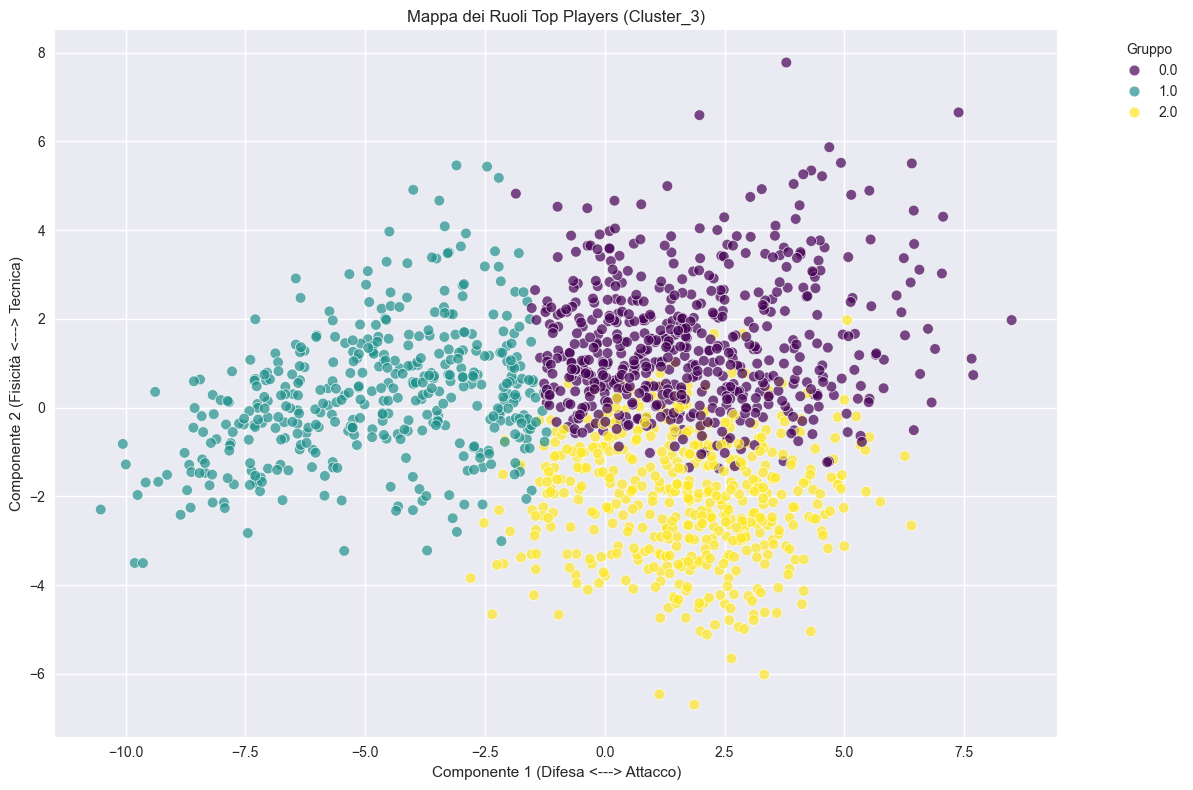

In [10]:
plt.figure(figsize=(12, 8))

# Scegli quale cluster visualizzare (Cluster_3 o Cluster_4)
cluster_da_visualizzare = 'Cluster_3' 

sns.scatterplot(
    x=pca_df['PC1'], 
    y=pca_df['PC2'], 
    hue=df_top[cluster_da_visualizzare], 
    palette='viridis', 
    alpha=0.7, 
    s=60
)

plt.title(f'Mappa dei Ruoli Top Players ({cluster_da_visualizzare})')
plt.xlabel('Componente 1 (Difesa <---> Attacco)')
plt.ylabel('Componente 2 (Fisicità <---> Tecnica)')
plt.legend(title='Gruppo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Funzione per vedere esempi reali di giocatori in ogni cluster
def mostra_esempi_cluster(cluster_id, n=10):
    print(f"--- ESEMPI DI GIOCATORI NEL CLUSTER {cluster_id} ---")
    # Prendi n giocatori a caso da quel cluster
    esempi = df_top[df_top['Cluster_3'] == cluster_id].sample(n)
    # Mostra Nome, Ruolo Reale e Overall
    display(esempi[['Name', 'Position', 'OVR']])

# Mostriamo 5 esempi per ogni gruppo trovato
mostra_esempi_cluster(0) 
mostra_esempi_cluster(1) 
mostra_esempi_cluster(2) 

--- ESEMPI DI GIOCATORI NEL CLUSTER 2 ---


,Name,Position,OVR
14576,Lisa Karl,RB,80
1276,Odsonne Edouard,ST,75
14777,Fiamma Benítez,CAM,76
684,Riquelme,LM,78
575,Veljko Birmančević,RW,78
14820,Jessica Naz,ST,76
14554,Nicole Billa,ST,80
1158,Riccardo Sottil,LW,76
213,Mohammed Kudus,RM,82
733,Igor Paixão,LW,77


--- ESEMPI DI GIOCATORI NEL CLUSTER 2 ---


,Name,Position,OVR
533,Martin Terrier,ST,79
1413,Joel Pohjanpalo,ST,75
14652,María Sánchez,LM,79
444,Boulaye Dia,ST,79
207,Ciro Immobile,ST,82
195,Gabriel Jesus,ST,82
14780,Jassina Blom,ST,76
1420,Nemanja Radonjić,CAM,75
1441,Diego Rossi,CAM,75
1157,Manor Solomon,LM,76


--- ESEMPI DI GIOCATORI NEL CLUSTER 2 ---


,Name,Position,OVR
14648,Lena Petermann,ST,79
14521,Esther,ST,81
1492,Ruben Vargas,LM,75
627,Rasmus Højlund,ST,78
35,Cristiano Ronaldo,ST,86
539,Nikola Vlašić,CAM,79
543,Yoane Wissa,LW,79
1034,Amine Harit,CM,76
1336,Nikola Krstović,ST,75
14865,Aïrine Fontaine,LM,75


vedere se è dataset scalato (errore) o quello di partenza

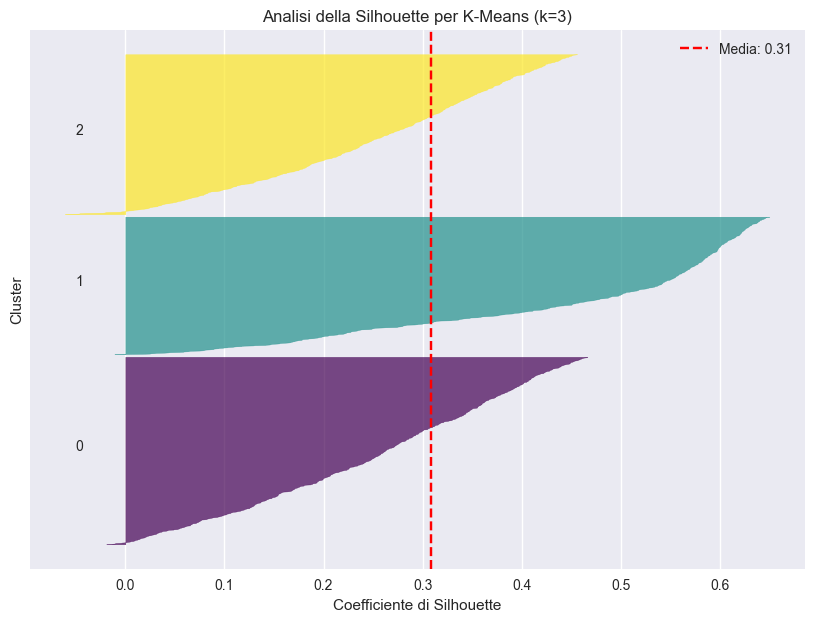

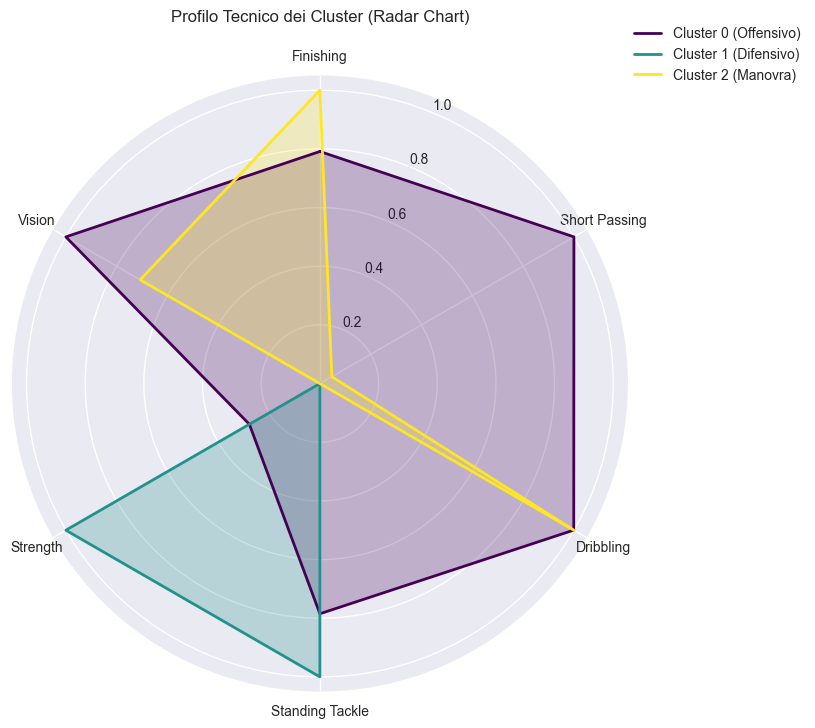

In [12]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

# --- PREPARAZIONE COLORI (Coerenti con lo scatter plot numerico 'viridis') ---
n_clusters = 3
cmap = plt.get_cmap('viridis')
# Estraiamo i colori esattamente come fa Seaborn per i valori numerici 0, 1, 2
colors = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]

# --- GRAFICO 1: SILHOUETTE ANALYSIS PLOT ---
cluster_labels = df_top['Cluster_3']
sample_silhouette_values = silhouette_samples(X_top_pca, cluster_labels)
silhouette_avg = silhouette_score(X_top_pca, cluster_labels)

fig, ax1 = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    # Utilizzo del colore coordinato
    color = colors[i]
    
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10 

ax1.set_title("Analisi della Silhouette per K-Means (k=3)")
ax1.set_xlabel("Coefficiente di Silhouette")
ax1.set_ylabel("Cluster")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Media: {silhouette_avg:.2f}')
ax1.set_yticks([]) 
ax1.legend()
plt.show()

# --- GRAFICO 2: RADAR CHART DEI CLUSTER ---
radar_features = ['Finishing', 'Short Passing', 'Dribbling', 'Standing Tackle', 'Strength', 'Vision']
cluster_means = df_top.groupby('Cluster_3')[radar_features].mean()
# Normalizzazione 0-1 per rendere il grafico leggibile
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
labels = ['Cluster 0 (Offensivo)', 'Cluster 1 (Difensivo)', 'Cluster 2 (Manovra)']

for i in range(n_clusters):
    values = cluster_means_norm.iloc[i].tolist()
    values += values[:1]
    
    # Utilizzo dello stesso colore coordinato
    color = colors[i]
    
    ax.plot(angles, values, color=color, linewidth=2, label=labels[i])
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)
plt.title('Profilo Tecnico dei Cluster (Radar Chart)', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

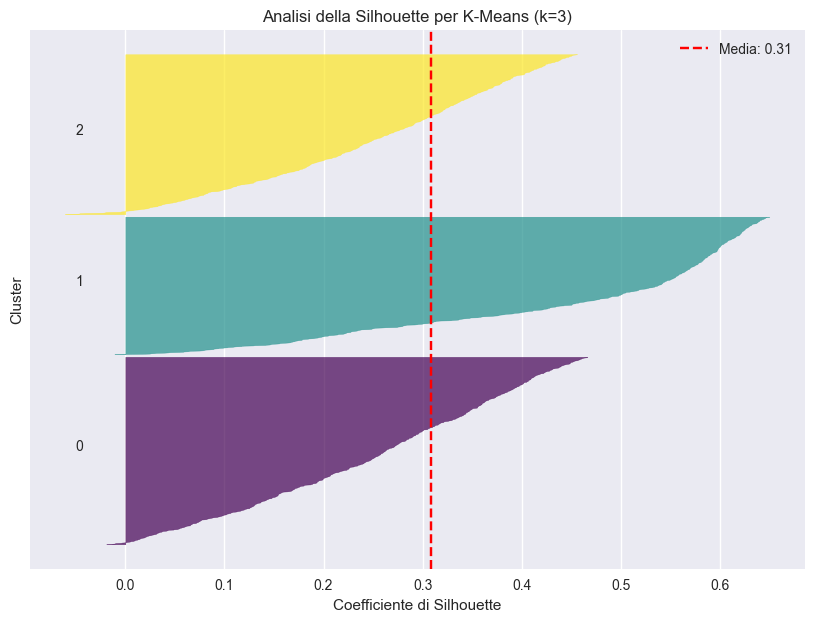

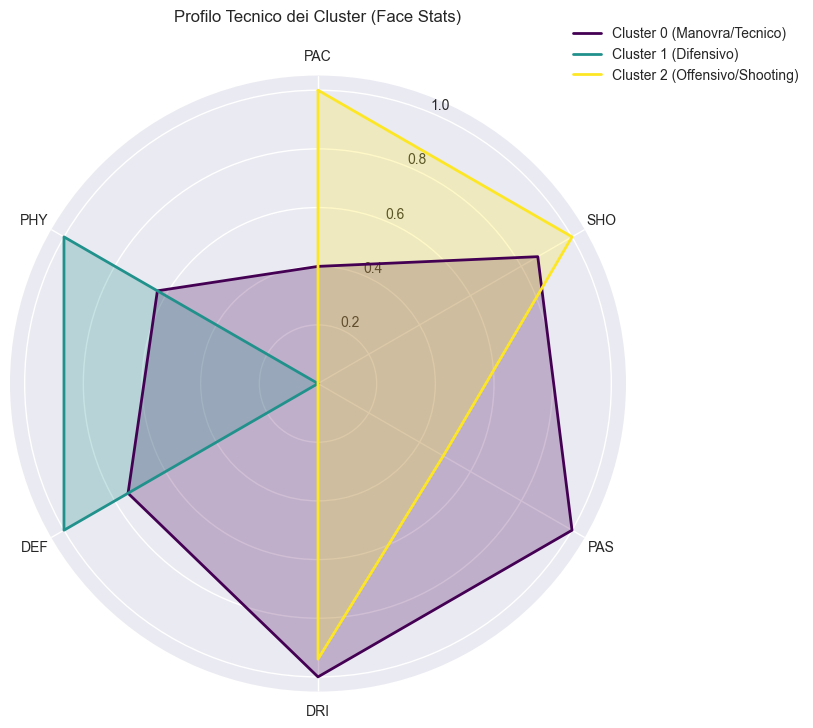

In [13]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

# --- PREPARAZIONE COLORI (Coerenti con lo scatter plot 'viridis') ---
n_clusters = 3
cmap = plt.get_cmap('viridis')
# Estraiamo i colori per i cluster 0, 1, 2
colors = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]

# --- GRAFICO 1: SILHOUETTE ANALYSIS PLOT ---
cluster_labels = df_top['Cluster_3']
sample_silhouette_values = silhouette_samples(X_top_pca, cluster_labels)
silhouette_avg = silhouette_score(X_top_pca, cluster_labels)

fig, ax1 = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10 

ax1.set_title("Analisi della Silhouette per K-Means (k=3)")
ax1.set_xlabel("Coefficiente di Silhouette")
ax1.set_ylabel("Cluster")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Media: {silhouette_avg:.2f}')
ax1.set_yticks([]) 
ax1.legend()
plt.show()

# --- GRAFICO 2: RADAR CHART DEI CLUSTER (Face Stats) ---
# Sostituisci questi nomi se le tue colonne hanno nomi diversi (es. 'Pace' invece di 'PAC')
radar_features = ['PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'] 
cluster_means = df_top.groupby('Cluster_3')[radar_features].mean()
# Normalizzazione per la visualizzazione
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# Etichette aggiornate con la corretta interpretazione
labels = ['Cluster 0 (Manovra/Tecnico)', 'Cluster 1 (Difensivo)', 'Cluster 2 (Offensivo/Shooting)']

for i in range(n_clusters):
    values = cluster_means_norm.iloc[i].tolist()
    values += values[:1]
    color = colors[i]
    ax.plot(angles, values, color=color, linewidth=2, label=labels[i])
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)
plt.title('Profilo Tecnico dei Cluster (Face Stats)', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()